<a href="https://colab.research.google.com/github/niniqoiii/The-Visual-Storyteller/blob/main/inference_IMPROVED_DRIVE_LINK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project — Inference Notebook

This notebook loads the trained Visual Storyteller model and defines the required inference function:

```python
def generate_caption(image_path: str, model: any) -> str:
    """
    Takes a path to an image and returns a generated caption string.
    """
```
This improved version uses **beam search** by default, which usually produces better captions than greedy decoding.

In [22]:
# Optional: install dependencies inside the notebook environment.
# Run this once if your environment is missing packages.
# %pip install -r requirements.txt

## 1. Imports and artifact loading

In [23]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import tokenizer_from_json
from tensorflow.keras.applications import EfficientNetB0

PROJECT_DIR = Path.cwd()
ARTIFACT_DIR = Path("/content")

MODEL_PATH = ARTIFACT_DIR / "caption_model_best.keras"
if not MODEL_PATH.exists():
    MODEL_PATH = ARTIFACT_DIR / "caption_model_best.keras"

TOKENIZER_PATH = ARTIFACT_DIR / "tokenizer.json"
CONFIG_PATH = ARTIFACT_DIR / "config.json"
FEATURE_EXTRACTOR_PATH = ARTIFACT_DIR / "feature_extractor.keras"

required = [MODEL_PATH, TOKENIZER_PATH, CONFIG_PATH]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing trained artifacts: " + ", ".join(missing) +
        ". Run data_and_training.ipynb first."
    )

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = json.load(f)

with open(TOKENIZER_PATH, "r", encoding="utf-8") as f:
    tokenizer = tokenizer_from_json(f.read())

model = tf.keras.models.load_model(MODEL_PATH, compile=False)

if FEATURE_EXTRACTOR_PATH.exists():
    feature_extractor = tf.keras.models.load_model(FEATURE_EXTRACTOR_PATH, compile=False)
else:
    # Fallback if feature extractor was not saved.
    feature_extractor = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        pooling="avg",
        input_shape=(config["image_size"][0], config["image_size"][1], 3),
    )
    feature_extractor.trainable = False

max_length = int(config["max_length"])
vocab_size = int(config["vocab_size"])
image_size = tuple(config["image_size"])
index_word = {idx: word for word, idx in tokenizer.word_index.items() if idx < vocab_size}

print("Loaded model:", MODEL_PATH)
print("Max caption length:", max_length)
print("Vocabulary size:", vocab_size)

Loaded model: /content/caption_model_best.keras
Max caption length: 36
Vocabulary size: 5000


In [24]:
from pathlib import Path
import zipfile

try:
    import gdown
except ImportError:
    !pip install -q gdown
    import gdown

DATA_DIR = Path("/content/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

ZIP_PATH = DATA_DIR / "caption_data.zip"
EXTRACT_DIR = DATA_DIR / "caption_data"

DRIVE_FILE_URL = "https://drive.google.com/file/d/1gwsWIb1idfEl3wDswVXcTcuzIoypTrWo/view?usp=sharing"

if not ZIP_PATH.exists():
    print("Downloading caption_data.zip from Google Drive...")
    gdown.download(DRIVE_FILE_URL, str(ZIP_PATH), quiet=False, fuzzy=True)
else:
    print("Dataset zip already exists:", ZIP_PATH)

if not EXTRACT_DIR.exists() or not any(EXTRACT_DIR.rglob("*.jpg")):
    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(EXTRACT_DIR)
else:
    print("Dataset already extracted.")

jpgs = list(EXTRACT_DIR.rglob("*.jpg"))
print("Found images:", len(jpgs))
print("Example image:", jpgs[0] if jpgs else "No image found")

Dataset zip already exists: /content/data/caption_data.zip
Dataset already extracted.
Found images: 8091
Example image: /content/data/caption_data/Images/3470303255_fbb41b8dd0.jpg


## 2. Image preprocessing and feature extraction

In [25]:
def preprocess_image_for_model(image_path: str):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, image_size)
    img = tf.cast(img, tf.float32)
    return tf.expand_dims(img, axis=0)


def extract_image_feature(image_path: str) -> np.ndarray:
    image_tensor = preprocess_image_for_model(image_path)
    feature = feature_extractor.predict(image_tensor, verbose=0)
    return feature.astype("float32")

## 3. Required inference function with beam search

The assignment requires `generate_caption(image_path: str, model: any) -> str`. The function below keeps that required signature and internally uses beam search with `BEAM_WIDTH = 3`.

A greedy version is also included for comparison.

In [26]:
BEAM_WIDTH = int(config.get("beam_width", 3))


def clean_generated_tokens(words):
    cleaned = []
    for w in words:
        if w in {"startseq", "endseq", "unk"}:
            continue
        cleaned.append(w)
    return " ".join(cleaned).strip()


def generate_caption_greedy(image_path: str, model: any) -> str:
    """
    Greedy baseline: chooses the highest-probability next word at each step.
    """
    feature = extract_image_feature(image_path)
    caption = "startseq"

    for _ in range(max_length):
        seq = tokenizer.texts_to_sequences([caption])[0]
        seq = pad_sequences([seq], maxlen=max_length, padding="pre")
        yhat = model.predict(
            {"image_features": feature, "caption_input": seq},
            verbose=0,
        )[0]
        next_id = int(np.argmax(yhat))
        next_word = index_word.get(next_id)

        if next_word is None or next_word == "endseq":
            break
        if next_word not in {"startseq", "unk"}:
            caption += " " + next_word

    return caption.replace("startseq", "").replace("endseq", "").strip()


def generate_caption(image_path: str, model: any) -> str:
    """
    Takes a path to an image and returns a generated caption string.
    Uses beam search for stronger sequence generation.
    """
    feature = extract_image_feature(image_path)
    sequences = [(["startseq"], 0.0)]

    for _ in range(max_length):
        candidates = []

        for words, score in sequences:
            if words[-1] == "endseq":
                candidates.append((words, score))
                continue

            caption = " ".join(words)
            seq = tokenizer.texts_to_sequences([caption])[0]
            seq = pad_sequences([seq], maxlen=max_length, padding="pre")
            yhat = model.predict(
                {"image_features": feature, "caption_input": seq},
                verbose=0,
            )[0]

            top_ids = np.argsort(yhat)[-BEAM_WIDTH:][::-1]
            for idx in top_ids:
                word = index_word.get(int(idx))
                if word is None or word == "startseq" or word == "unk":
                    continue
                prob = float(yhat[idx])
                candidates.append((words + [word], score + np.log(prob + 1e-9)))

        if not candidates:
            break

        sequences = sorted(
            candidates,
            key=lambda item: item[1] / max(1, len(item[0])),
            reverse=True,
        )[:BEAM_WIDTH]

        if all(words[-1] == "endseq" for words, _ in sequences):
            break

    best_words = sequences[0][0]
    return clean_generated_tokens(best_words)


## 4. Demonstration on unseen test images

The training notebook writes `artifacts/test_images.txt`, which contains images from the held-out test split.

Using IMAGE_DIR: /content/data/caption_data/Images
Unseen test images available: 810
Beam width: 3


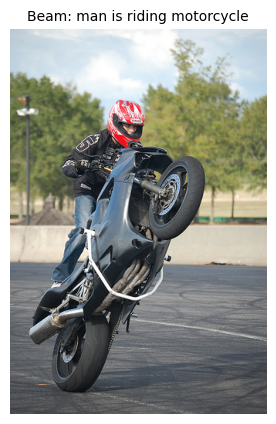

IMAGE: 2616508003_fa5ca5780d.jpg
GREEDY: man is riding motorcycle
BEAM: man is riding motorcycle
--------------------------------------------------------------------------------


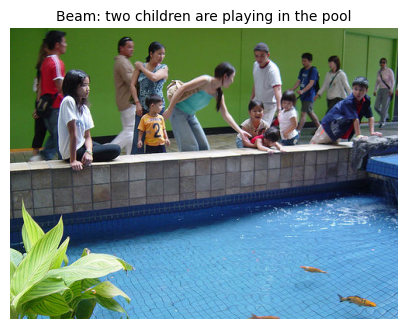

IMAGE: 12830823_87d2654e31.jpg
GREEDY: two children are playing in the pool
BEAM: two children are playing in the pool
--------------------------------------------------------------------------------


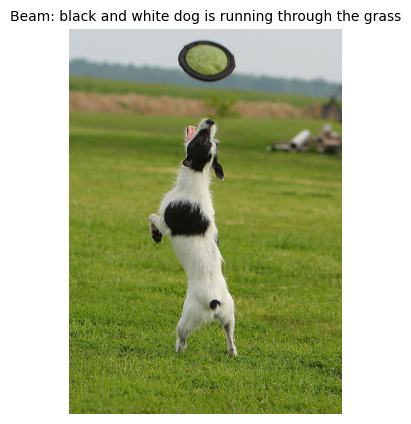

IMAGE: 2438085746_588dce8724.jpg
GREEDY: black and white dog is running through the grass
BEAM: black and white dog is running through the grass
--------------------------------------------------------------------------------


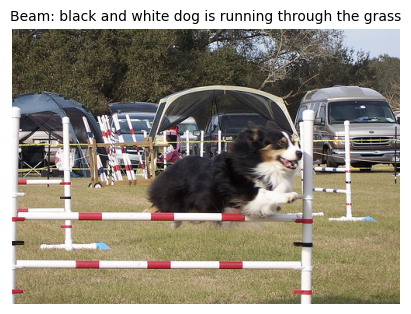

IMAGE: 2629445284_83390e83af.jpg
GREEDY: black and white dog is jumping over hurdle
BEAM: black and white dog is running through the grass
--------------------------------------------------------------------------------


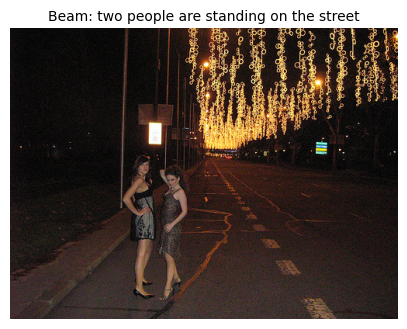

IMAGE: 3128514681_a51b415c31.jpg
GREEDY: man in red shirt is standing on the street
BEAM: two people are standing on the street
--------------------------------------------------------------------------------


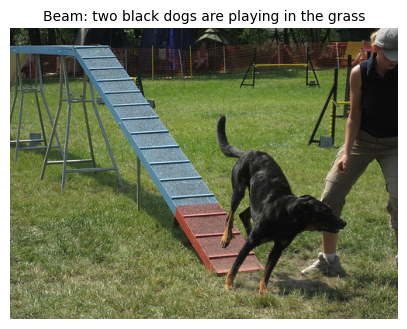

IMAGE: 537479916_c033897fac.jpg
GREEDY: black dog is running in the grass
BEAM: two black dogs are playing in the grass
--------------------------------------------------------------------------------


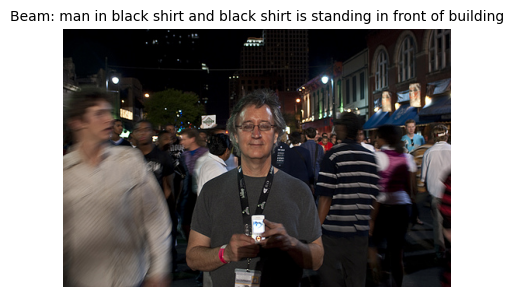

IMAGE: 3461110860_37ef15af8e.jpg
GREEDY: man in black shirt and black shirt and black shirt and black shirt are standing in front of the street
BEAM: man in black shirt and black shirt is standing in front of building
--------------------------------------------------------------------------------


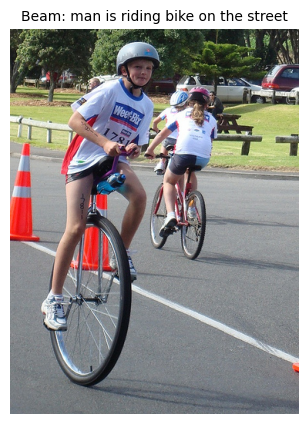

IMAGE: 2403078014_4b1d6f8bde.jpg
GREEDY: man in red shirt is riding bike on the street
BEAM: man is riding bike on the street
--------------------------------------------------------------------------------


,image_path,greedy_caption,beam_caption
0,/content/data/caption_data/Images/2616508003_f...,man is riding motorcycle,man is riding motorcycle
1,/content/data/caption_data/Images/12830823_87d...,two children are playing in the pool,two children are playing in the pool
2,/content/data/caption_data/Images/2438085746_5...,black and white dog is running through the grass,black and white dog is running through the grass
3,/content/data/caption_data/Images/2629445284_8...,black and white dog is jumping over hurdle,black and white dog is running through the grass
4,/content/data/caption_data/Images/3128514681_a...,man in red shirt is standing on the street,two people are standing on the street
5,/content/data/caption_data/Images/537479916_c0...,black dog is running in the grass,two black dogs are playing in the grass
6,/content/data/caption_data/Images/3461110860_3...,man in black shirt and black shirt and black s...,man in black shirt and black shirt is standing...
7,/content/data/caption_data/Images/2403078014_4...,man in red shirt is riding bike on the street,man is riding bike on the street


In [27]:
from pathlib import Path
import random
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# Beam width
BEAM_WIDTH = 3

# Find the real Images folder
possible_image_dirs = [
    Path("/content/data/caption_data/Images"),
    Path("/content/data/caption_data/caption_data/Images"),
    Path("/content/Images"),
    Path("/content/data/Images"),
]

IMAGE_DIR = None

for d in possible_image_dirs:
    if d.exists() and any(d.glob("*.jpg")):
        IMAGE_DIR = d
        break

# If standard folders do not work, search all /content
if IMAGE_DIR is None:
    jpgs = list(Path("/content").rglob("*.jpg"))
    if not jpgs:
        raise FileNotFoundError(
            "No .jpg images found. Extract/download caption_data.zip first."
        )
    IMAGE_DIR = jpgs[0].parent

print("Using IMAGE_DIR:", IMAGE_DIR)

# Build lookup by filename
image_lookup = {p.name: p for p in IMAGE_DIR.glob("*.jpg")}

# Read test_images.txt, but fix old paths using filenames
TEST_IMAGES_PATH = ARTIFACT_DIR / "test_images.txt"

if TEST_IMAGES_PATH.exists():
    raw_test_paths = TEST_IMAGES_PATH.read_text(encoding="utf-8").splitlines()
    test_image_paths = []

    for old_path in raw_test_paths:
        filename = Path(old_path).name
        if filename in image_lookup:
            test_image_paths.append(str(image_lookup[filename]))

    print("Unseen test images available:", len(test_image_paths))
else:
    test_image_paths = [str(p) for p in IMAGE_DIR.glob("*.jpg")]
    print("test_images.txt not found, using all images:", len(test_image_paths))

if not test_image_paths:
    raise FileNotFoundError("No valid test images found after remapping paths.")

print("Beam width:", BEAM_WIDTH)


def show_caption_result(image_path: str):
    greedy_caption = generate_caption_greedy(image_path, model)
    beam_caption = generate_caption(image_path, model)

    img = Image.open(image_path)

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Beam: " + beam_caption, fontsize=10)
    plt.show()

    print("IMAGE:", Path(image_path).name)
    print("GREEDY:", greedy_caption)
    print("BEAM:", beam_caption)
    print("-" * 80)

    return greedy_caption, beam_caption


sample_paths = random.sample(test_image_paths, min(8, len(test_image_paths)))

results = []

for p in sample_paths:
    greedy_cap, beam_cap = show_caption_result(p)
    results.append({
        "image_path": p,
        "greedy_caption": greedy_cap,
        "beam_caption": beam_cap,
    })

results_df = pd.DataFrame(results)
results_df

## 5. Success and failure case analysis

In [28]:
# Create an editable analysis table for the final report/notebook.
analysis_df = results_df.copy()
analysis_df["case_type"] = "success_or_failure"
analysis_df["comment"] = "Write a short explanation after inspecting the image."
analysis_df

,image_path,greedy_caption,beam_caption,case_type,comment
0,/content/data/caption_data/Images/2616508003_f...,man is riding motorcycle,man is riding motorcycle,success_or_failure,Write a short explanation after inspecting the...
1,/content/data/caption_data/Images/12830823_87d...,two children are playing in the pool,two children are playing in the pool,success_or_failure,Write a short explanation after inspecting the...
2,/content/data/caption_data/Images/2438085746_5...,black and white dog is running through the grass,black and white dog is running through the grass,success_or_failure,Write a short explanation after inspecting the...
3,/content/data/caption_data/Images/2629445284_8...,black and white dog is jumping over hurdle,black and white dog is running through the grass,success_or_failure,Write a short explanation after inspecting the...
4,/content/data/caption_data/Images/3128514681_a...,man in red shirt is standing on the street,two people are standing on the street,success_or_failure,Write a short explanation after inspecting the...
5,/content/data/caption_data/Images/537479916_c0...,black dog is running in the grass,two black dogs are playing in the grass,success_or_failure,Write a short explanation after inspecting the...
6,/content/data/caption_data/Images/3461110860_3...,man in black shirt and black shirt and black s...,man in black shirt and black shirt is standing...,success_or_failure,Write a short explanation after inspecting the...
7,/content/data/caption_data/Images/2403078014_4...,man in red shirt is riding bike on the street,man is riding bike on the street,success_or_failure,Write a short explanation after inspecting the...
